### Extracting/creating the Type 1 diabetes subgraph from [PrimeKG](https://zitniklab.hms.harvard.edu/projects/PrimeKG/): Host Layer

In [26]:
import pandas as pd

#Import data needed
primekg_nodes = pd.read_csv('dataverse_files/nodes.csv')
primekg = pd.read_csv('dataverse_files/kg.csv')

/tmp/ipykernel_398916/3118190825.py:5: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  primekg = pd.read_csv('dataverse_files/kg.csv')


Removing edge duplicates and save for faster calls

Removing unneeded nodes: Drugs, Exposure, Cellular_Component, Molecular_Function, Anatomy. 

Removing phenotype absent relation

In [27]:
#pkg = primekg.copy()
#row_values = pkg[['relation', 'display_relation','x_index','x_type','x_name','y_index','y_type','y_name']].agg(frozenset, axis = 1)
#wpkg =  pkg[['relation', 'display_relation','x_index','x_type','x_name','y_index','y_type','y_name']].groupby(row_values).first()
#wpkg.to_csv(r"t1dm_wpkg_23_07_26.csv", sep=',', encoding='utf-8', index=False)

In [28]:
wpkg = pd.read_csv('t1dm_wpkg_23_07_26.csv')

In [29]:
wpkg = wpkg[~(wpkg['x_type'].isin(['drug','exposure','molecular_function','cellular_component','anatomy'])) & ~(wpkg['y_type'].isin(['drug','exposure','molecular_function','cellular_component','anatomy']))]
wpkg = wpkg[~(wpkg['display_relation'] == 'phenotype absent')]

In [30]:
wpkg_old = wpkg


Creating helper functions for reconciling the disease-phenotype representations of key entities

Key layer 1 entities as found in primekg_nodes.csv

Reconcilations/conversions were done such that:
Direct pathogen connection -> disease/infection
No direct pathogen connection -> effect/phenotype


Note that: 
- Bacteremia is strictly saved as an effect/phenotype. Converted to disease.
- Penetrating foot ulcers is strictly saved as an effect/phenotype. Converted to disease.
- Merging Recurrent UTIs (effect/phenotype) with UTI (disease)
- obesity disorder strictly saved as disease. Converted to effect/phenotype.

Goal:

key_diseases = {'pneumonia':'disease', 
 'urinary tract infection (disease)':'disease', 
 'cellulitis (disease)': 'disease', 
 'tuberculosis': 'disease', 
 'Penetrating foot ulcers': 'disease', 
 'folliculitis': 'disease', 
 'osteomyelitis (disease)': 'disease', 
 'otitis externa': 'disease', 
 'melioidosis': 'disease', 
 'periodontitis': 'disease', 
 'Bacteremia': 'disease'}

key_eps = {'Hyperglycemia': 'effect/phenotype', 
 'Immune dysregulation': 'effect/phenotype', 
 'Immunodeficiency': 'effect/phenotype', 
 'Hypoinsulinemia': 'effect/phenotype', 
 'peripheral neuropathy': 'effect/phenotype', 
 'obesity disorder': 'effect/phenotype', 
 'Systemic autoinflammation': 'effect/phenotype' 
 'Increased reactive oxygen species production': 'effect/phenotype'}

 Note that after a search of the previous key entities but with a focus on Type 1 diabetes mellitus the only major change was Insulin resistance --> Hypoinsulinemia which is due to the underlying autoimmune beta cell destruction in Type 1 diabetes. 

In [31]:
key_vals = ['pneumonia','urinary tract infection (disease)','cellulitis (disease)','tuberculosis','Penetrating foot ulcers','folliculitis','osteomyelitis (disease)','otitis externa','melioidosis', 
       'periodontitis','Bacteremia', 'Hypoinsulinemia','Hyperglycemia', 'Immune dysregulation', 'Immunodeficiency', 'Peripheral neuropathy','obesity disorder', 'Systemic autoinflammation', 
       'Increased reactive oxygen species production']

In [32]:
#Lists below contain only the key entities that are duplicated/for which conversion is required

#phenotype -> disease
pe_to_d1 =['Type I diabetes mellitus','Type II diabetes mellitus','Pneumonia','Recurrent urinary tract infections', 'Folliculitis', 'Otitis externa', 'Periodontitis', 'Bacteremia', 'Penetrating foot ulcers']
pe_to_d2 = ['type 1 diabetes mellitus','type 2 diabetes mellitus','pneumonia','urinary tract infection (disease)', 'folliculitis', 'otitis externa', 'periodontitis', 'Bacteremia', 'Penetrating foot ulcers']

#pe_df1 = primekg_nodes[primekg_nodes['node_name'].isin(pe_to_d1)]
pe_df2 = primekg_nodes[primekg_nodes['node_name'].isin(pe_to_d2)]

pe_df = pe_df2[['node_index','node_type','node_name']]

#disease -> phenotype
d_to_pe1 = ['hyperglycemia', 'immunodeficiency',  'peripheral neuropathy', 'obesity disorder']
d_to_pe2 = ['Hyperglycemia', 'Immunodeficiency',  'Peripheral neuropathy', 'obesity disorder']

#d_df1 = primekg_nodes[primekg_nodes['node_name'].isin(d_to_pe1)]
d_df2 = primekg_nodes[primekg_nodes['node_name'].isin(d_to_pe2)]

d_df = d_df2[['node_index','node_type','node_name']]

In [33]:
#phenotype -> disease

def x_reconcile_pd(df,phenotype,disease):

    relation_swap = {'phenotype_phenotype':'disease_phenotype_positive', 'disease_phenotype_positive': 'disease_disease', 'phenotype_protein': 'disease_protein'}
    display_relation_swap = {'phenotype_phenotype':'phenotype present', 'disease_phenotype_positive': 'parent-child', 'phenotype_protein': 'associated with'}
    
    relations = df[df['x_name'] == phenotype]['relation'].unique()

    if len(relations)>0:
        def temporary_function(row):
            row[['relation','display_relation','x_index','x_type','x_name']] = [relation_swap[relation],display_relation_swap[relation],pe_df[pe_df['node_name'] == disease]['node_index'].values[0],'disease',disease]
            return row
        
        for relation in relations:
            df = df.apply(lambda row: temporary_function(row) if (row['x_name'] == phenotype) & (row['relation'] == relation) else row,axis = 1)
            
    return df



def y_reconcile_pd(df,phenotype,disease):

    relation_swap = {'phenotype_phenotype':'disease_phenotype_positive', 'disease_phenotype_positive': 'disease_disease', 'phenotype_protein': 'disease_protein'}
    display_relation_swap = {'phenotype_phenotype':'phenotype present', 'disease_phenotype_positive': 'parent-child', 'phenotype_protein': 'associated with'}
    
    relations = df[df['y_name'] == phenotype]['relation'].unique()

    if len(relations)>0:
        def temporary_function(row):
            row[['relation','display_relation','y_index','y_type','y_name']] = [relation_swap[relation],display_relation_swap[relation],pe_df[pe_df['node_name'] == disease]['node_index'].values[0],'disease',disease]
            return row
        
        for relation in relations:
            df = df.apply(lambda row: temporary_function(row) if (row['y_name'] == phenotype) & (row['relation'] == relation) else row,axis = 1)

    return df

In [34]:
#disease -> phenotype
def x_reconcile_dp(df,disease,phenotype):

    relation_swap = {'disease_phenotype_positive':'phenotype_phenotype', 'disease_disease':'disease_phenotype_positive', 'disease_protein': 'phenotype_protein'}
    display_relation_swap = {'disease_phenotype_positive':'parent-child', 'disease_disease': 'phenotype present', 'disease_protein': 'associated with'}
    
    relations = df[df['x_name'] == disease]['relation'].unique()

    if len(relations)>0:
        def temporary_function(row):
            row[['relation','display_relation','x_index','x_type','x_name']] = [relation_swap[relation],display_relation_swap[relation],d_df[d_df['node_name'] == phenotype]['node_index'].values[0],'effect/phenotype',phenotype]
            return row
        
        for relation in relations:
            df = df.apply(lambda row: temporary_function(row) if (row['x_name'] == disease) & (row['relation'] == relation) else row,axis = 1)
    return df


def y_reconcile_dp(df,disease,phenotype):

    relation_swap = {'disease_phenotype_positive':'phenotype_phenotype', 'disease_disease':'disease_phenotype_positive', 'disease_protein': 'phenotype_protein'}
    display_relation_swap = {'disease_phenotype_positive':'parent-child', 'disease_disease': 'phenotype present', 'disease_protein': 'associated with'}
    
    relations = df[df['y_name'] == disease]['relation'].unique()

    if len(relations)>0:
        def temporary_function(row):
            row[['relation','display_relation','y_index','y_type','y_name']] = [relation_swap[relation],display_relation_swap[relation],d_df[d_df['node_name'] == phenotype]['node_index'].values[0],'effect/phenotype',phenotype]
            return row
        
        for relation in relations:
            df = df.apply(lambda row: temporary_function(row) if (row['y_name'] == disease) & (row['relation'] == relation) else row,axis = 1)
            
    return df

Reconcilling key entities for Layer 1 



In [35]:
#Applying x_reconcile_pd and y_reconcile_pd first to merge type 1 diabetes mellitus and Type I disabetes mellitus
wpkg = x_reconcile_pd(wpkg_old,'Type I diabetes mellitus' ,'type 1 diabetes mellitus')
wpkg = y_reconcile_pd(wpkg,'Type I diabetes mellitus' ,'type 1 diabetes mellitus')

In [36]:
#Applying x_reconcile_pd and y_reconcile_pd to also merge type 2 diabetes mellitus and Type II disabetes mellitus
wpkg = x_reconcile_pd(wpkg,'Type II diabetes mellitus' ,'type 2 diabetes mellitus')
wpkg = y_reconcile_pd(wpkg,'Type II diabetes mellitus' ,'type 2 diabetes mellitus')

In [37]:
#checking
wpkg[wpkg['y_name'] == 'Type I diabetes mellitus']

,relation,display_relation,x_index,x_type,x_name,y_index,y_type,y_name


In [38]:
wpkg[wpkg['y_name'] == 'Type II diabetes mellitus']

,relation,display_relation,x_index,x_type,x_name,y_index,y_type,y_name


In [39]:
num_diseases = len(key_vals[0:11])

In [40]:
num_effect = len(key_vals) - num_diseases

In [41]:
#Applying x_reconcile_pd and y_reconcile_pd to merge key diseases with their effect reps 
for j in range(len(pe_to_d1)-2):
    print(pe_to_d2[j+2])
    wpkg = x_reconcile_pd(wpkg, pe_to_d1[j+1] , pe_to_d2[j+1])
    wpkg = y_reconcile_pd(wpkg, pe_to_d1[j+1], pe_to_d2[j+1])

pneumonia
urinary tract infection (disease)
folliculitis
otitis externa
periodontitis
Bacteremia
Penetrating foot ulcers


In [42]:
#checking
wpkg[wpkg['y_name'] == 'Pneumonia']

,relation,display_relation,x_index,x_type,x_name,y_index,y_type,y_name


In [43]:
#Applying x_reconcile_dp and y_reconcile_dp to merge key effect/phenotypes with their disease reps
for j in range(len(d_to_pe1)):
    print(d_to_pe2[j])
    wpkg = x_reconcile_dp(wpkg, d_to_pe1[j] , d_to_pe2[j])
    wpkg = y_reconcile_dp(wpkg, d_to_pe1[j], d_to_pe2[j])

Hyperglycemia
Immunodeficiency
Peripheral neuropathy
obesity disorder


In [44]:
#checking
wpkg[(wpkg['y_name'] == 'hyperglycemia')]

,relation,display_relation,x_index,x_type,x_name,y_index,y_type,y_name


In [45]:
#Removing cases where there was a relation between the different expressions since they now are entity -> same entity. 
wpkg = wpkg[~((wpkg['x_name'] == wpkg['y_name']) & (wpkg['x_type'] == wpkg['y_type']))]

In [46]:
#Since reconcilation may render certain relations twice (eg. Type I diabetes mellitus -> entity & type 1 diabetes mellitus -> entity will now become type 1 diabetes -> entity twice)
# We find and maintain one of such relations
wpkg = wpkg.groupby(wpkg.agg(frozenset,axis = 1)).first()


In [47]:
#reset index
wpkg = wpkg.reset_index(drop=True)

 Building shorter connections between T1DM and the core effects and comorbid infections of interest. 
(Manual inspection reveals that some of these connections may come after 3 or more indirect connections, making it difficult to incorporate naturally. Literature backs these connections up so I believe that it is valid.)

In [48]:
#Confirming those that are not directly connected
wpkg[(wpkg['x_name']=='type 1 diabetes mellitus') & (wpkg['y_name'].isin(key_vals))] 

,relation,display_relation,x_index,x_type,x_name,y_index,y_type,y_name


In [49]:
wpkg[(wpkg['y_name']=='type 1 diabetes mellitus') & (wpkg['x_name'].isin(key_vals))]

,relation,display_relation,x_index,x_type,x_name,y_index,y_type,y_name


In [50]:
direct_disease = {'relation': ['disease_disease']*num_diseases, 'display_relation': ['parent-child']*num_diseases, 'x_index': primekg_nodes[primekg_nodes['node_name'] == 'type 1 diabetes mellitus']['node_index'].tolist()*num_diseases,'x_type': primekg_nodes[primekg_nodes['node_name'] == 'type 1 diabetes mellitus']['node_type'].tolist()*num_diseases, 'x_name': primekg_nodes[primekg_nodes['node_name'] == 'type 1 diabetes mellitus']['node_name'].tolist()*num_diseases,'y_index':primekg_nodes[primekg_nodes['node_name'].isin(key_vals[0:11])]['node_index'].tolist(),'y_type':['disease']*num_diseases,'y_name': primekg_nodes[primekg_nodes['node_name'].isin(key_vals[0:11])]['node_name'].tolist()}
direct_disease_df = pd.DataFrame(direct_disease)
direct_disease_df.head(3)

,relation,display_relation,x_index,x_type,x_name,y_index,y_type,y_name
0,disease_disease,parent-child,28552,disease,type 1 diabetes mellitus,32505,disease,tuberculosis
1,disease_disease,parent-child,28552,disease,type 1 diabetes mellitus,33333,disease,melioidosis
2,disease_disease,parent-child,28552,disease,type 1 diabetes mellitus,33588,disease,osteomyelitis (disease)


In [51]:
direct_effect = {'relation': ['disease_phenotype_positive']*(num_effect), 'display_relation': ['phenotype present']*(num_effect), 'x_index': primekg_nodes[primekg_nodes['node_name'] == 'type 1 diabetes mellitus']['node_index'].tolist()*(num_effect),
                 'x_type': primekg_nodes[primekg_nodes['node_name'] == 'type 1 diabetes mellitus']['node_type'].tolist()*(num_effect), 'x_name': primekg_nodes[primekg_nodes['node_name'] == 'type 1 diabetes mellitus']['node_name'].tolist()*(num_effect),
                 'y_index':primekg_nodes[primekg_nodes['node_name'].isin(key_vals[11:len(key_vals)])]['node_index'].tolist(),'y_type':['effect/phenotype']*(num_effect),'y_name': primekg_nodes[primekg_nodes['node_name'].isin(key_vals[11:len(key_vals)])]['node_name'].tolist()}
direct_effect_df = pd.DataFrame(direct_effect)
direct_effect_df.head(3) 

,relation,display_relation,x_index,x_type,x_name,y_index,y_type,y_name
0,disease_phenotype_positive,phenotype present,28552,disease,type 1 diabetes mellitus,22457,effect/phenotype,Peripheral neuropathy
1,disease_phenotype_positive,phenotype present,28552,disease,type 1 diabetes mellitus,23973,effect/phenotype,Immunodeficiency
2,disease_phenotype_positive,phenotype present,28552,disease,type 1 diabetes mellitus,25526,effect/phenotype,Hyperglycemia


In [52]:
pre_extraction_wpkg = pd.concat([wpkg,direct_disease_df,direct_effect_df],ignore_index=True)

In [53]:
len(pre_extraction_wpkg)

848939

Same as for T2DM

Subgraph extraction with the following algorithm: 
1) We find all relations where T1DM is either a source node or a target node. 
2) If T1DM is connected to a disease, find the disease-phenotype/gene relations and concatenate.
3) If T1DM is connected to a phenotype, find the phenotype-phenotype/gene relations and concatenate. 
4) If T1DM is connected to a gene, find the gene-gene/pathway/BP/phenotype relations and concatenate. 

None of these includes connections back to diseases as this is not a direct comorbidity.



In [54]:
#1.
t1dmx = pre_extraction_wpkg[(pre_extraction_wpkg['x_name'] == 'type 1 diabetes mellitus')] 
t1dmx.head(3)

,relation,display_relation,x_index,x_type,x_name,y_index,y_type,y_name
322274,disease_disease,parent-child,28552,disease,type 1 diabetes mellitus,27834,disease,autoimmune polyendocrine
334833,disease_disease,parent-child,28552,disease,type 1 diabetes mellitus,97684,disease,"diabetes mellitus, insulin-dependent, X-linked..."
343485,disease_disease,parent-child,28552,disease,type 1 diabetes mellitus,30438,disease,H syndrome


In [55]:
t1dmy = pre_extraction_wpkg[(pre_extraction_wpkg['y_name'] == 'type 1 diabetes mellitus')] 
t1dmy.head(3)

,relation,display_relation,x_index,x_type,x_name,y_index,y_type,y_name
13567,disease_disease,parent-child,28876,disease,combined immunodeficiency due to LRBA deficiency,28552,disease,type 1 diabetes mellitus
16601,disease_disease,parent-child,29112,disease,Pearson syndrome,28552,disease,type 1 diabetes mellitus
89402,disease_disease,parent-child,29024,disease,"hepatitis, fulminant viral, susceptibility to",28552,disease,type 1 diabetes mellitus


In [56]:
#function for step 2,3,4
def extraction_fxn(df1,df2,main_df):

    relevant1 = df1[['y_type','y_index']]
    relevant2 = df2[['x_type','x_index']]

    relevant1d = relevant1[relevant1['y_type'] == 'disease']
    relevant1p = relevant1[relevant1['y_type'] == 'effect/phenotype']
    relevant1g = relevant1[relevant1['y_type'] == 'gene/protein']

    relevant2d = relevant2[relevant2['x_type'] == 'disease']
    relevant2p = relevant2[relevant2['x_type'] == 'effect/phenotype']
    relevant2g = relevant2[relevant2['x_type'] == 'gene/protein']

    relevantd = pd.concat([relevant1d.rename(columns = {'y_type':'type','y_index':'index'}),relevant2d.rename(columns = {'x_type':'type','x_index':'index'})], ignore_index=True)
    relevantp = pd.concat([relevant1p.rename(columns = {'y_type':'type','y_index':'index'}),relevant2p.rename(columns = {'x_type':'type','x_index':'index'})], ignore_index=True)
    relevantg = pd.concat([relevant1g.rename(columns = {'y_type':'type','y_index':'index'}),relevant2g.rename(columns = {'x_type':'type','x_index':'index'})], ignore_index=True)

    list_disease_indices = relevantd['index'].values.tolist()
    list_ep_indices = relevantp['index'].values.tolist()
    list_gene_indices = relevantg['index'].values.tolist()

    
    def disease_connections(list_disease_indices,df):
        for index in list_disease_indices:
            df_disease_addx = main_df[(main_df['x_index'] == index)] 
            df_disease_addy = main_df[(main_df['y_index'] == index)] #Both include connections to diseases,genes,phenotype

            save_x = df_disease_addx[(df_disease_addx['y_type'] == 'disease') & (df_disease_addx['y_index'].isin(list_disease_indices))]#saving connections to diseases that were connected to t2dm
            save_y = df_disease_addy[(df_disease_addy['x_type'] == 'disease') & (df_disease_addy['x_index'].isin(list_disease_indices))]#if they exist, that is. 

            df_disease_addx = df_disease_addx[~(df_disease_addx['y_type'] == 'disease')] 
            df_disease_addy = df_disease_addy[~(df_disease_addy['x_type'] == 'disease')] #dropping disease connections per algorithm

            df = pd.concat([df,df_disease_addx,df_disease_addy, save_x, save_y], ignore_index=True)

        return df

    def phenotype_connections(list_ep_indices,df):
        for index in list_ep_indices:
            df_ep_add = main_df[(main_df['x_index'] == index) | (main_df['y_index'] == index)]#includes disease,phenotype, gene connections

            df_ep_add = df_ep_add[~(df_ep_add['x_type'] == 'disease') & ~(df_ep_add['y_type'] == 'disease')]#dropping disease connections

            df = pd.concat([df,df_ep_add], ignore_index=True)

        return df
  
    def gene_connections(list_gene_indices,df):
        for index in list_gene_indices:
            df_gene_add = main_df[(main_df['x_index'] == index) | (main_df['y_index'] == index)]#includes disease,phenotype,gene,BP, pathway connections

            df_gene_add = df_gene_add[~(df_gene_add['x_type'] == 'disease') & ~(df_gene_add['y_type'] == 'disease')]#dropping disease connections

            df = pd.concat([df,df_gene_add], ignore_index=True)

        return df
  
    
    add_d_df = disease_connections(list_disease_indices,df2)
    add_e_df = phenotype_connections(list_ep_indices,df1)
    add_g_df = gene_connections(list_gene_indices,df1)
    

    return pd.concat([add_d_df,add_e_df,add_g_df[len(df1):len(add_g_df)]],ignore_index=True) #indexing of add_g_df is to avoid the repetition of the original members of df1

    
    

In [57]:
extracted = extraction_fxn(t1dmx,t1dmy,pre_extraction_wpkg)

In [58]:
# a circle back thought + edit after neo4j exploration: a lot of 'syndrome' related illnesses were related to T1DM as an effect/phenotype. 
# These end up looking like major hubs which I think shifts the focus of this analysis from infection/AMR. 
# Deleting these for this reason 

#Uncomment if syndromes wrt T1DM are not overwhelming

#extracted = extracted[~(extracted['x_name'].str.contains('syndrome')) & ~(extracted['y_name'].str.contains('syndrome'))]

In [59]:
#Once again, duplicates will arise from extracting process. 
#Example: T1DM -> Gene1, T1DM -> Gene2 and Gene1 -> Gene2. Hence Gene1 -> Gene2 will appear twice. 

extracted = extracted.groupby(extracted.agg(frozenset, axis= 1)).first().reset_index(drop = True)

In [60]:
extracted.head()

,relation,display_relation,x_index,x_type,x_name,y_index,y_type,y_name
0,disease_disease,parent-child,28876,disease,combined immunodeficiency due to LRBA deficiency,28552,disease,type 1 diabetes mellitus
1,protein_protein,ppi,5124,gene/protein,ITPR3,12615,gene/protein,FGL2
2,protein_protein,ppi,5124,gene/protein,ITPR3,11675,gene/protein,TRPC4
3,protein_protein,ppi,4814,gene/protein,CHRNA3,5124,gene/protein,ITPR3
4,protein_protein,ppi,5124,gene/protein,ITPR3,3493,gene/protein,TRPC3


Emphasising immune dysfunction by creating a new entity type: immune_effect/phenotype

In [61]:
# Criteria for possible immune_effect/phenotype
# must contain lymph, NK, T cell, immune, antibody, B cells, CD, cytokines, Ig immunoglobins, IL, inflammation, inflammatory, Leuko, Phago, Macrophages, neutrophil, monocyte, monokine, 
# basophil, eosinophil, TNF, histio, antigen, immunodeficiency, rheumatoid factor, interleukin, interferon, IFN, TCR.
# keywords selected from https://www.ncbi.nlm.nih.gov/books/NBK230991/ and literatue readings. 

In [62]:
def immune_rowfxn(row):

    keywords = ['lymph','NK','T cell','immune','immuno','antibody','B cells','CD','cytokines','IgA','IgG','IgM','IgE','IgD','IL-','inflammation','inflammatory','leuko','Phago','Macrophages'
            ,'neutrophil','monocyte','monokine','basophil','eosinophil','TNF','histio','antigen','immunodeficiency','rheumatoid factor','interleukin','interferon'
            ,'IFN','TCR', 'autoimmune', 'globulin']
    
    relation_swap = {'disease_phenotype_positive':'disease_immune_phenotype_positive','phenotype_phenotype':'immune_phenotype_phenotype','phenotype_protein':'immune_phenotype_protein'}
    display_relation_swap = {'disease_phenotype_positive':'immune phenotype present','phenotype_phenotype':'parent-child', 'phenotype_protein':'associated with'}
    double_relation_swap = {'phenotype_phenotype':'immune_phenotype_immune_phenotype'}

    res = row.str.contains('|'.join(keywords), case = False)
    
    if (row['y_type'] == 'effect/phenotype') & (res['y_name'] == True) & ((row['x_type'] != 'effect/phenotype')|(res['x_name'] == False)):
        row['y_type'] = 'immune_effect/phenotype'
        row['display_relation'] = display_relation_swap[row['relation']]
        row['relation'] = relation_swap[row['relation']]     

    if (row['x_type'] == 'effect/phenotype') & (res['x_name']== True) & ((row['y_type'] != 'effect/phenotype')|(res['y_name'] == False)):
        row['x_type'] = 'immune_effect/phenotype'
        row['display_relation'] = display_relation_swap[row['relation']]
        row['relation'] = relation_swap[row['relation']]
      
    if (row['x_type'] == 'effect/phenotype') & (row['y_type'] == 'effect/phenotype') & (res['x_name']== True) & (res['y_name']== True):
        row['x_type'] = 'immune_effect/phenotype'
        row['y_type'] = 'immune_effect/phenotype'
        row['display_relation'] = display_relation_swap[row['relation']]
        row['relation'] = double_relation_swap[row['relation']]
    
    return row

In [63]:
#test = extracted[extracted['y_name'] == 'Immunodeficiency'].head(20).iloc[6,:]
#test
#immune_rowfxn(test)

In [64]:
immune_adjusted_extracted = extracted.apply(lambda x: immune_rowfxn(x), axis=1)

In [76]:
immune_adjusted_extracted[immune_adjusted_extracted['y_name'] == 'Type II diabetes mellitus'].head(3)

,relation,display_relation,x_index,x_type,x_name,y_index,y_type,y_name


In [66]:
immune_adjusted_extracted.to_csv(r't1dm_host_layer_data.csv', index= False)

For Neo4j exploration

In [67]:
ia_extracted_edges = immune_adjusted_extracted[['relation','display_relation','x_index','y_index']].rename(columns = {'relation':':TYPE','x_index':':START_ID','y_index':':END_ID'})

In [68]:
nodes_new = pd.concat([immune_adjusted_extracted[['x_name','x_type','x_index']].rename(columns={'x_index':'node_index','x_type':'node_type','x_name':'node_name'}),immune_adjusted_extracted[['y_name','y_type','y_index']].rename(columns={'y_index':'node_index','y_type':'node_type','y_name':'node_name'})],ignore_index=True).groupby(['node_index']).first()

In [69]:
ia_extracted_nodes = nodes_new.reset_index().rename(columns={'node_type':':LABEL', 'node_index':'node_index:ID'})

In [70]:
ia_extracted_nodes.head(3)

,node_index:ID,node_name,:LABEL
0,6,EIF3I,gene/protein
1,10,LRP5,gene/protein
2,15,EGR1,gene/protein


In [71]:
ia_extracted_edges.to_csv(r"ia_t1dm_subgraph_edges.csv", sep = ',', encoding = 'utf-8', index = False)
ia_extracted_nodes.to_csv(r"ia_t1dm_subgraph_nodes.csv",sep = ',', encoding = 'utf-8', index = False)

<Axes: >

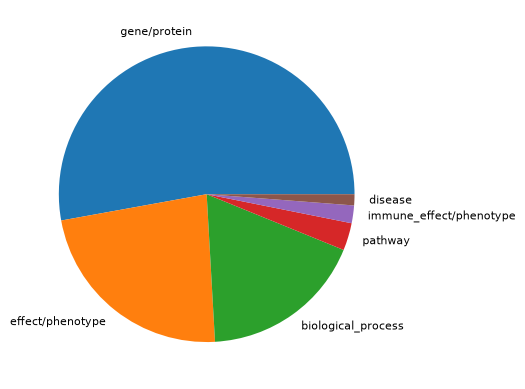

In [72]:
ia_extracted_nodes[':LABEL'].value_counts(normalize=True).plot.pie(y=':LABEL', fontsize = 7.8, ylabel = '')